In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df_ml  = pd.read_csv("../cleaned_datasets/df_ml.csv")
df_raw = pd.read_parquet("../cleaned_datasets/resale_with_all_features.parquet")


df_ml shape : (180003, 97)
Treated (near_tier1_1km=1) : 32,865 (18.3%)


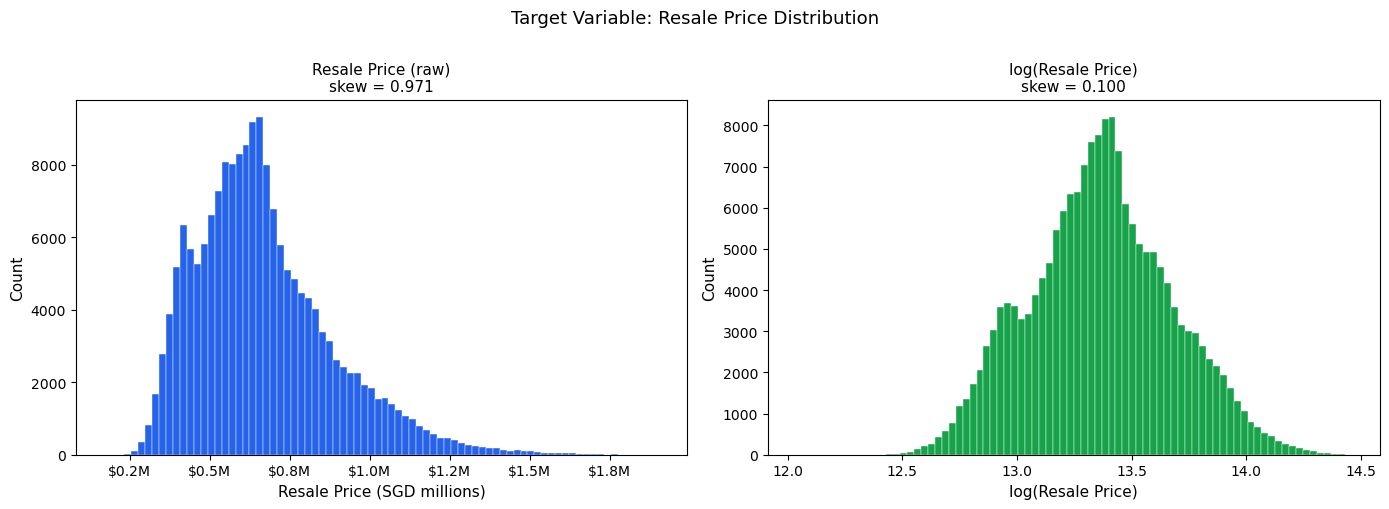

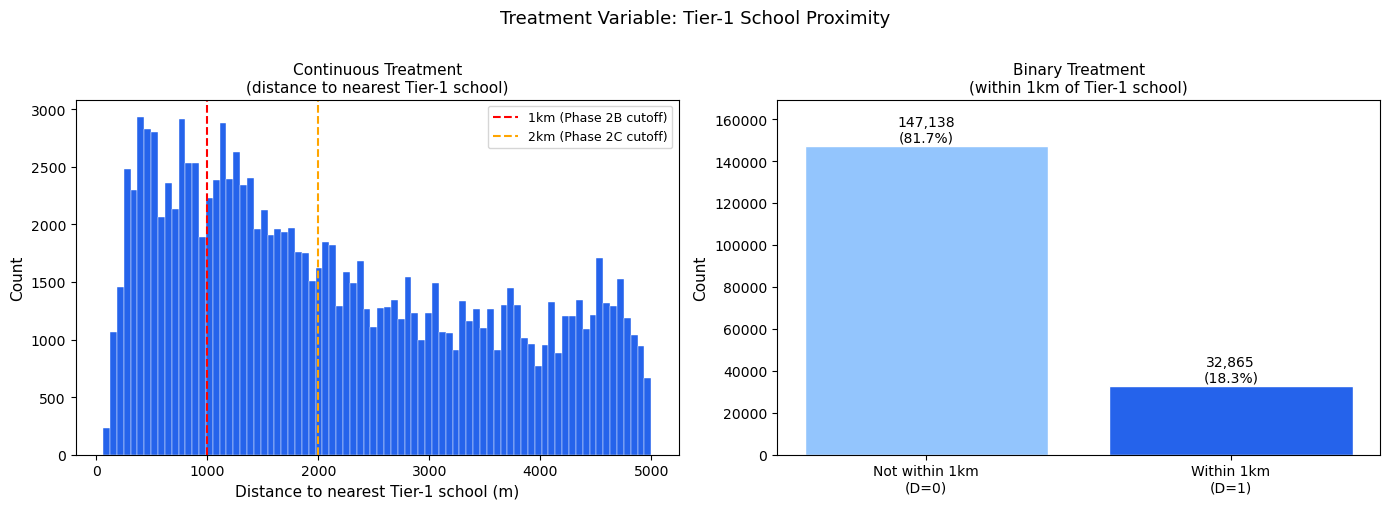

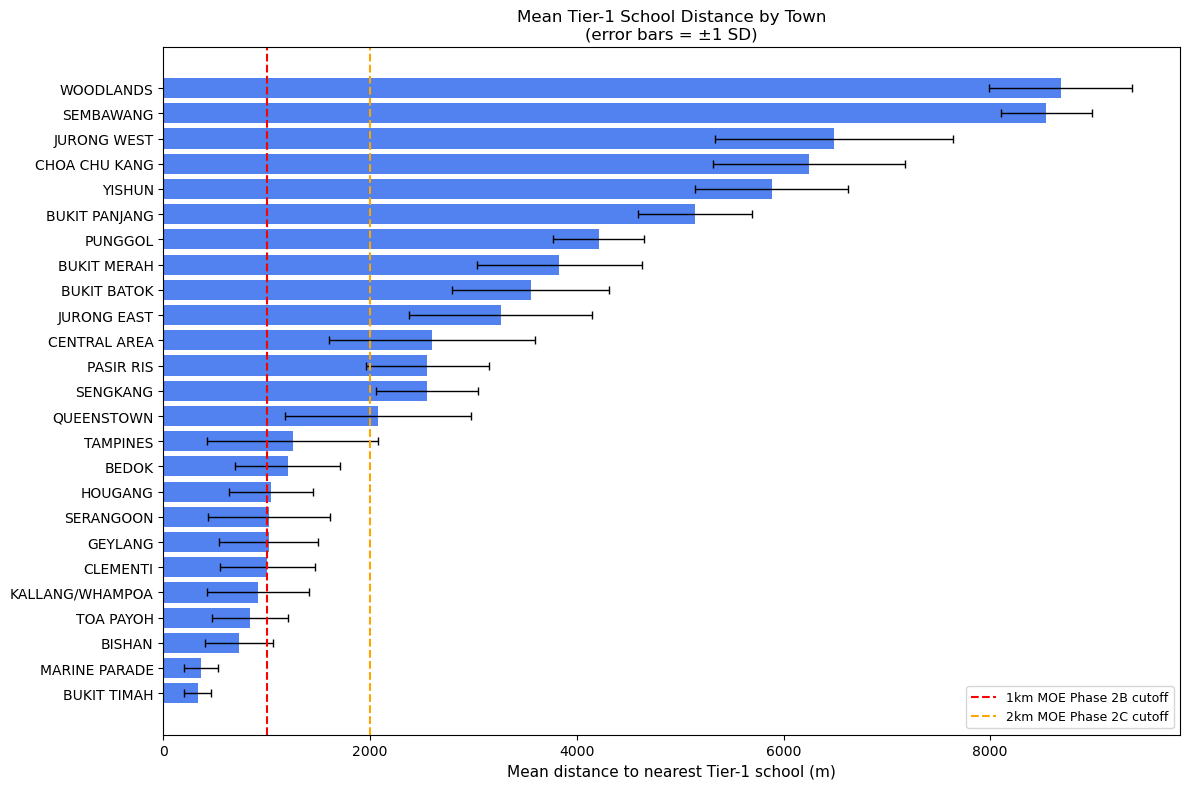

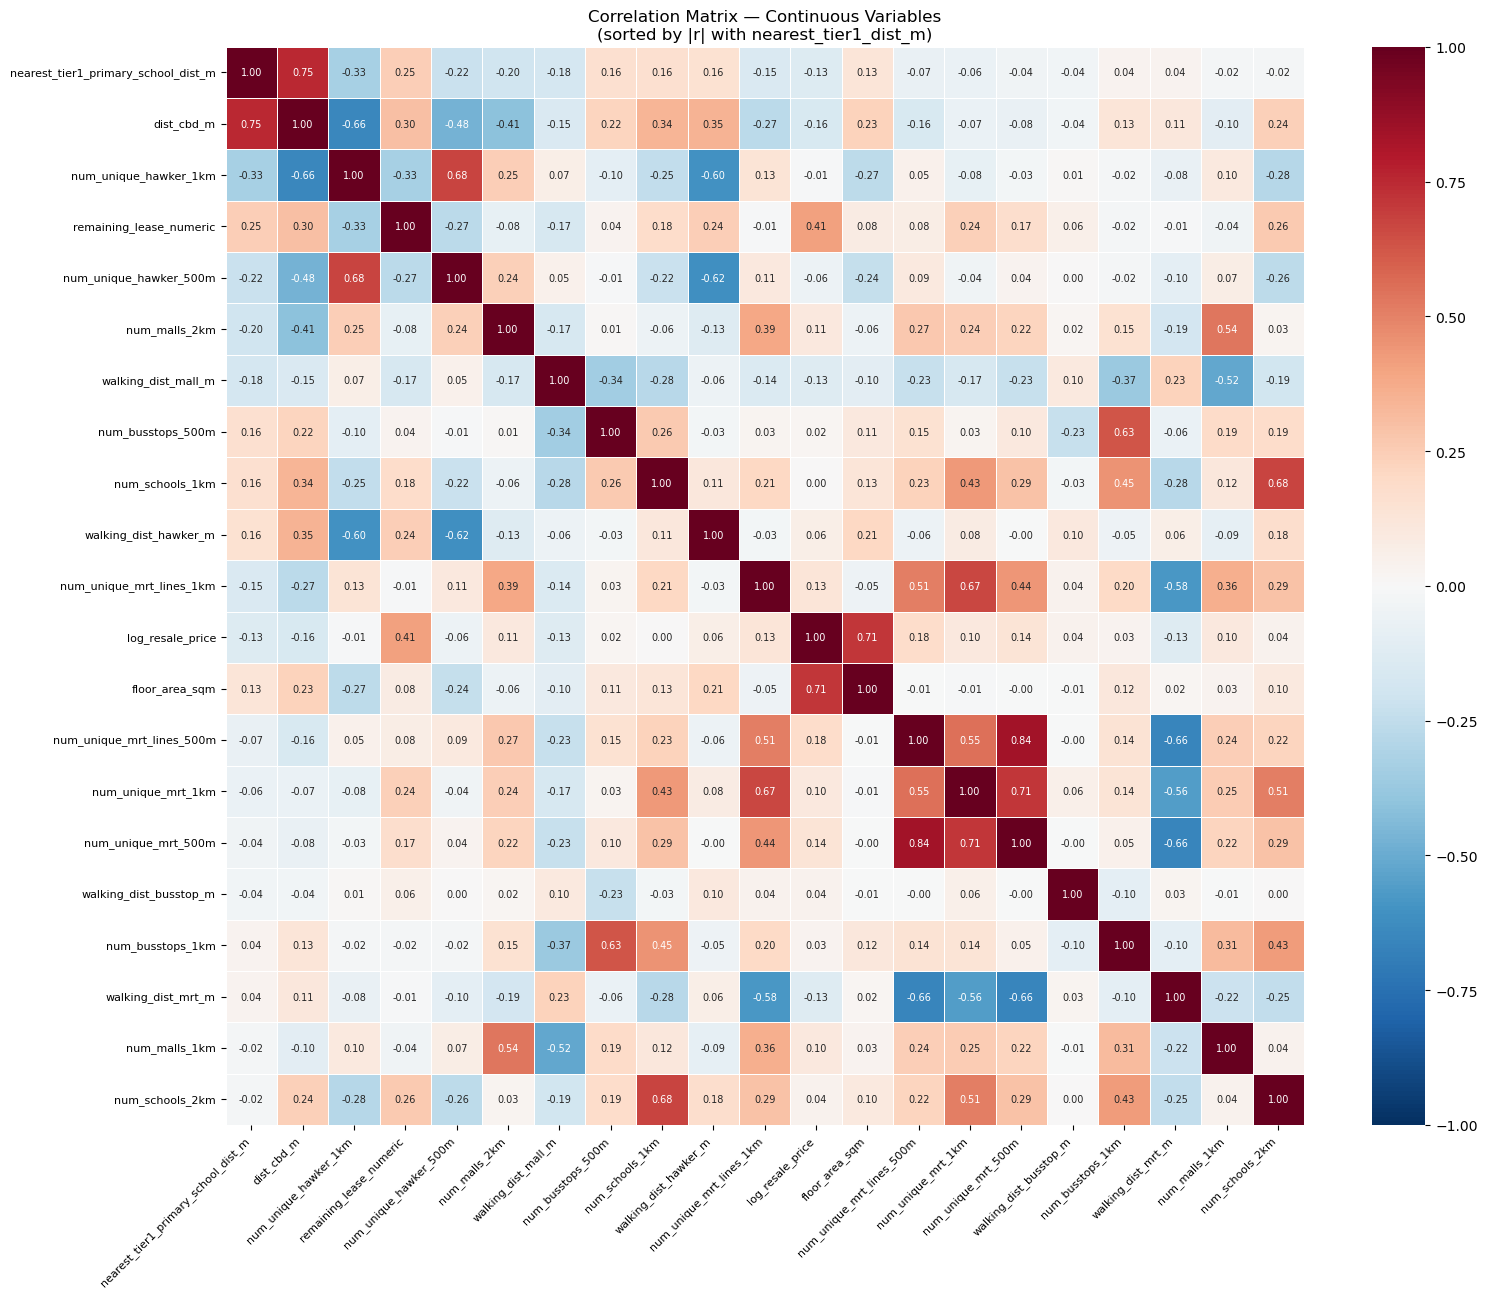

In [4]:
# recover town labels from dummies for plotting
town_cols     = [c for c in df_ml.columns if c.startswith("town_")]
df_ml["town"] = (df_ml[town_cols]
                 .idxmax(axis=1)
                 .str.replace("town_", "", regex=False))

# recover flat_type and storey_range from dummies
flat_type_cols    = [c for c in df_ml.columns if c.startswith("flat_type_")]
storey_range_cols = [c for c in df_ml.columns if c.startswith("storey_range_")]

df_ml["flat_type"]    = (df_ml[flat_type_cols]
                         .idxmax(axis=1)
                         .str.replace("flat_type_", "", regex=False))
df_ml["storey_range"] = (df_ml[storey_range_cols]
                          .idxmax(axis=1)
                          .str.replace("storey_range_", "", regex=False))

target       = "log_resale_price"
d_continuous = "nearest_tier1_primary_school_dist_m"
d_binary     = "near_tier1_1km"

print(f"df_ml shape : {df_ml.shape}")
print(f"Treated (near_tier1_1km=1) : {df_ml[d_binary].sum():,} "
      f"({df_ml[d_binary].mean():.1%})")

#  1. Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.exp(df_ml[target]) / 1e6, bins=80,
             color="#2563EB", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Resale Price (SGD millions)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title(f"Resale Price (raw)\nskew = {np.exp(df_ml[target]).skew():.3f}",
                  fontsize=11)
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:.1f}M")
)

axes[1].hist(df_ml[target], bins=80,
             color="#16A34A", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("log(Resale Price)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title(f"log(Resale Price)\nskew = {df_ml[target].skew():.3f}",
                  fontsize=11)

plt.suptitle("Target Variable: Resale Price Distribution",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("target_dist.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Treatment variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# continuous treatment — distance in metres
axes[0].hist(df_ml[d_continuous][df_ml[d_continuous] <= 5000],
             bins=80, color="#2563EB", edgecolor="white", linewidth=0.3)
axes[0].axvline(1000, color="red",    linestyle="--",
                linewidth=1.5, label="1km (Phase 2B cutoff)")
axes[0].axvline(2000, color="orange", linestyle="--",
                linewidth=1.5, label="2km (Phase 2C cutoff)")
axes[0].set_xlabel("Distance to nearest Tier-1 school (m)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_title("Continuous Treatment\n(distance to nearest Tier-1 school)",
                  fontsize=11)
axes[0].legend(fontsize=9)

# binary treatment — prevalence
treat_counts = df_ml[d_binary].value_counts().sort_index()
bars = axes[1].bar(["Not within 1km\n(D=0)", "Within 1km\n(D=1)"],
                   treat_counts.values,
                   color=["#93C5FD", "#2563EB"], edgecolor="white")
for bar, val in zip(bars, treat_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 500,
                 f"{val:,}\n({val/len(df_ml):.1%})",
                 ha="center", va="bottom", fontsize=10)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title("Binary Treatment\n(within 1km of Tier-1 school)",
                  fontsize=11)
axes[1].set_ylim(0, treat_counts.max() * 1.15)

plt.suptitle("Treatment Variable: Tier-1 School Proximity",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("treatment_dist.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Mean Tier-1 school distance by town
town_school_dist = (
    df_ml.groupby("town")[d_continuous]
    .agg(["mean", "std", "count"])
    .sort_values("mean")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(
    town_school_dist["town"],
    town_school_dist["mean"],
    xerr    = town_school_dist["std"],
    color   = "#2563EB",
    alpha   = 0.8,
    capsize = 3,
    error_kw = {"elinewidth": 1, "ecolor": "black"},
)
ax.axvline(1000, color="red",    linestyle="--",
           linewidth=1.5, label="1km MOE Phase 2B cutoff")
ax.axvline(2000, color="orange", linestyle="--",
           linewidth=1.5, label="2km MOE Phase 2C cutoff")
ax.set_xlabel("Mean distance to nearest Tier-1 school (m)", fontsize=11)
ax.set_title("Mean Tier-1 School Distance by Town\n(error bars = ±1 SD)",
             fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("town_school_distance.png", dpi=150, bbox_inches="tight")
plt.show()

#  4. Correlation matrix — continuous vars + treatment 
continuous_cols = [
    "floor_area_sqm", "remaining_lease_numeric", "dist_cbd_m",
    "num_unique_mrt_500m",    "num_unique_mrt_1km",
    "num_unique_mrt_lines_500m", "num_unique_mrt_lines_1km",
    "walking_dist_mrt_m",     "num_busstops_500m",
    "num_busstops_1km",       "walking_dist_busstop_m",
    "num_unique_hawker_500m", "num_unique_hawker_1km",
    "walking_dist_hawker_m",  "num_malls_1km",
    "num_malls_2km",          "walking_dist_mall_m",
    "num_schools_1km",        "num_schools_2km",
    d_continuous,             target,
]

continuous_cols = [c for c in continuous_cols if c in df_ml.columns]
corr_matrix     = df_ml[continuous_cols].corr()

# sort by absolute correlation with treatment
sort_order  = (
    corr_matrix[d_continuous]
    .abs()
    .sort_values(ascending=False)
    .index.tolist()
)
corr_matrix = corr_matrix.loc[sort_order, sort_order]

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    annot      = True,
    fmt        = ".2f",
    cmap       = "RdBu_r",
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    square     = True,
    linewidths = 0.4,
    ax         = ax,
    annot_kws  = {"size": 7},
)
ax.set_title("Correlation Matrix — Continuous Variables\n"
             "(sorted by |r| with nearest_tier1_dist_m)", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


df_cat shape  : (180003, 23)
df_cat columns: ['town', 'flat_type', 'storey_range', 'floor_area_sqm', 'flat_model', 'nearest_tier1_primary_school_dist_m', 'num_unique_mrt_500m', 'num_unique_mrt_1km', 'num_unique_mrt_lines_500m', 'num_unique_mrt_lines_1km', 'walking_dist_mrt_m', 'num_busstops_500m', 'num_busstops_1km', 'walking_dist_busstop_m', 'num_unique_hawker_500m', 'num_unique_hawker_1km', 'walking_dist_hawker_m', 'num_malls_1km', 'num_malls_2km', 'walking_dist_mall_m', 'dist_cbd_m', 'remaining_lease_numeric', 'log_resale_price']

Sorting by correlation with : nearest_tier1_primary_school_dist_m

Correlation matrix shape : (22, 22)

Top 15 correlations with nearest_tier1_primary_school_dist_m:
nearest_tier1_primary_school_dist_m    1.000000
dist_cbd_m                             0.750387
num_unique_hawker_1km                 -0.330672
town                                   0.294260
remaining_lease_numeric                0.248931
num_unique_hawker_500m                -0.222385
num_ma

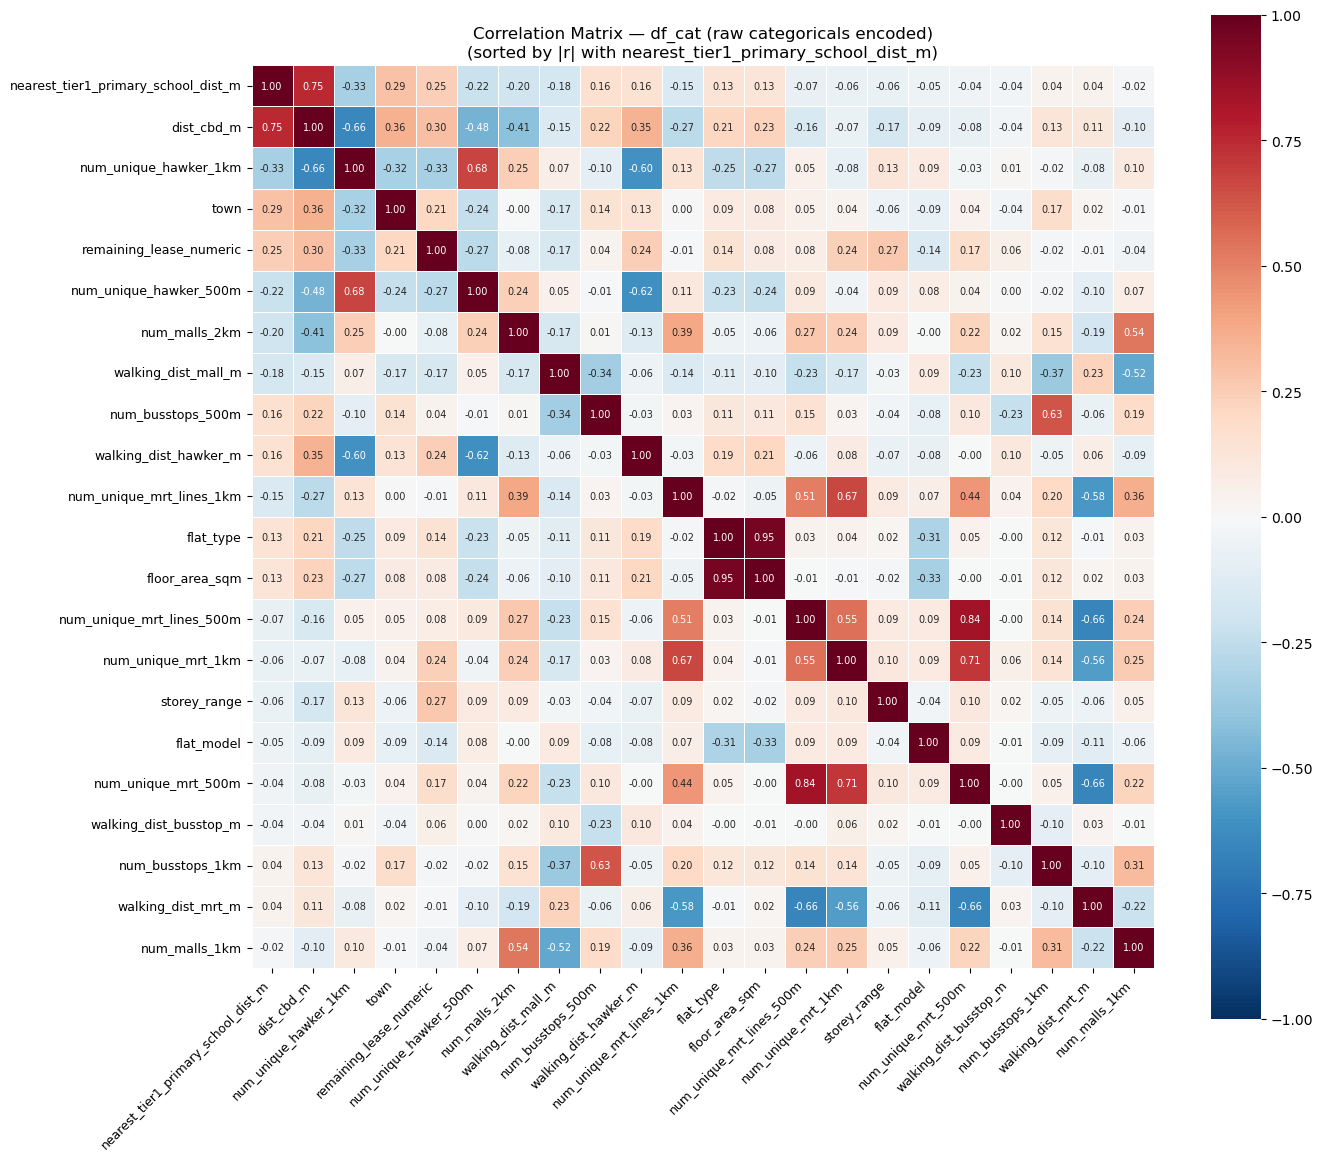

Saved → correlation_matrix_cat.png


In [ ]:
# Correlation matrix — df_cat (raw categoricals)
# encode categoricals as integer codes for correlation

df_cat = pd.read_pickle("../cleaned_datasets/df_cat.pkl")

print(f"df_cat shape  : {df_cat.shape}")
print(f"df_cat columns: {df_cat.columns.tolist()}")

df_cat_encoded = df_cat.copy()
for col in df_cat_encoded.select_dtypes(include="category").columns:
    df_cat_encoded[col] = df_cat_encoded[col].cat.codes

# check which treatment variable is available
# df_cat dropped leakage cols but kept nearest_tier1_dist_m
treat_col = d_continuous if d_continuous in df_cat_encoded.columns else d_binary
print(f"\nSorting by correlation with : {treat_col}")

exclude      = ["log_resale_price", "log_price_per_sqm", "price_per_sqm"]
corr_cols    = [c for c in df_cat_encoded.columns if c not in exclude]

corr_cat     = df_cat_encoded[corr_cols].corr()

sort_order   = (
    corr_cat[treat_col]
    .abs()
    .sort_values(ascending=False)
    .index.tolist()
)
corr_cat = corr_cat.loc[sort_order, sort_order]

# full matrix ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_cat,
    annot      = True,
    fmt        = ".2f",
    cmap       = "RdBu_r",
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    square     = True,
    linewidths = 0.4,
    ax         = ax,
    annot_kws  = {"size": 7},
)
ax.set_title("Correlation Matrix — df_cat (raw categoricals encoded)\n"
             f"(sorted by |r| with {treat_col})", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig("correlation_matrix_cat.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → correlation_matrix_cat.png")